The purpose of this file is to analyze the .txt files exported by the ATEX software

I want to plot my data in a way that is comparable to how Ernould chapter 4 plots his database

Plots 

When disorientation angle is varied: 
- Fig 2a - Max and Min error of von mises strain versus disorientation 
- Fig 9a  - Max relative error versus disortination, plotted for each of the von mises strain values as a line plot 
- Fig 9c - Relative error versus disorientation for each of the components as a scatter plot 


When strain is varied: 
- Fig 2b - Max and Min error of disorientation angle versus strain 
- Fig 9b - see above 

###  Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import conversions
import os
import ErnouldsMethod
import utilities

/Users/crestiennedechaine/opt/anaconda3/envs/hrebsd/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Before you can read in the file make sure that the line DATA BEGIN is commented

# Inputs

In [2]:
#EMEBSD version 
#file that contains all of the deformation gradient data exported from Al_results visulalization
filename = '/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/Al-DiffRefPatter-SuperMegaLargeArea-rows50to150-columns150to350_Mar132025_npyfiles/Al-DiffRefPatter-SuperMegaLargeArea-rows50to150-columns150to350_homographies_Mar132025.npy'
#How many Rows and Columns were in the original EBSD scan?
Rows = 100 #y columns 
Columns = 200 #x columns 

#results folder path
foldername = f'/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/Al-DiffRefPatter-SuperMegaLargeArea-rows50to150-columns150to350_homographies_Mar132025/'

os.makedirs(foldername, exist_ok=True)

tilt = 70.0 + 8.0  # sample tilt in degrees
sample_Frame = True #whether the deformation gradient data is in the sample frame or the detector frame, used to determine whether to rotate the deformation gradient data by the rotation matrix R

# grain_ids = np.load('/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/Al-x150to175y75to125_segment_Mar102025_npyfiles/Al-x150to175y75to125_segment_ids_Mar102025.npy')

# kam = np.load('/Users/crestiennedechaine/Scripts/DIC-HREBSD/DIC-HREBSD/results/Al-x150to175y75to125_segment_Mar102025_npyfiles/Al-x150to175y75to125_segment_kam_Mar102025.npy')


In [3]:
# img = grain_ids.reshape(Rows, Columns)

# masked = np.ma.masked_where(img > 10, img)

# plt.figure(figsize=(10,8))
# plt.imshow(masked, cmap='tab20')
# plt.colorbar(label='Grain ID')
# plt.title('Grain IDs ≤ 10')
# plt.xlabel('Column Index')
# plt.ylabel('Row Index')
# plt.show()

In [4]:
# # reshape KAM
# kam = kam.reshape(Rows, Columns)

# plt.figure(figsize=(10,8))

# im = plt.imshow(kam, cmap='viridis', vmin=0, vmax=2)

# plt.colorbar(im, label='KAM (degrees)')
# plt.title('KAM Map')
# plt.xlabel('Column Index')
# plt.ylabel('Row Index')

# plt.show()

# Conversion to Homography to Strain

In [5]:
h = np.load(
        filename
    )

#h is in column major order convert h to row major order for comparison
h11 = h[:, 0]
h12 = h[:, 1]
h13 = h[:, 2]
h21 = h[:, 3]
h22 = h[:, 4]
h23 = h[:, 5]
h31 = h[:, 6]
h32 = h[:, 7]

#restack h in row major order
h_calc = np.stack((h11, h12, h13, h21, h22, h23, h31, h32), axis=1)


F = conversions.h2F(h_calc, np.array([(0.4776-0.5)*480, (0.5833-0.5)*480, (480*0.670697)]))

#pring F shape
print(F.shape)
epsilon, omega = conversions.F2strain(F)
print(epsilon.shape)
print((480*11.2*0.670697))



(20000, 3, 3)
(20000, 3, 3)
3605.6670719999997


In [6]:
R = utilities.samp2detectorATEX(tilt)

if sample_Frame:
    #need to rotate epsilon and omega by R 
    for i in range(epsilon.shape[0]): 
        epsilon[i, :, :] = R.T @ epsilon[i,:,:] @ R
        omega[i,:, :] = R.T @ omega[i, :, :] @ R

This is the code to read in a .csv file generated by pyHREBSD

In [7]:

e11 = epsilon[:, 0, 0]
e12 = epsilon[:, 0, 1]
e13 = epsilon[:, 0, 2]
e22 = epsilon[:, 1, 1]
e23 = epsilon[:, 1, 2]
e33 = epsilon[:, 2, 2]
w13 = omega[:, 0, 2]
w21 = omega[:, 1, 0]
w32 = omega[:, 2, 1]

#convert the rotation components to degrees
w13 = np.degrees(w13)
w21 = np.degrees(w21)
w32 = np.degrees(w32)


In [8]:
#reshape all components to Rows x Columns
e11 = e11.reshape((Rows, Columns))
e12 = e12.reshape((Rows, Columns))
e13 = e13.reshape((Rows, Columns))
e22 = e22.reshape((Rows, Columns))
e23 = e23.reshape((Rows, Columns))
e33 = e33.reshape((Rows, Columns))
w13 = w13.reshape((Rows, Columns))
w21 = w21.reshape((Rows, Columns))
w32 = w32.reshape((Rows, Columns))


# Plotting

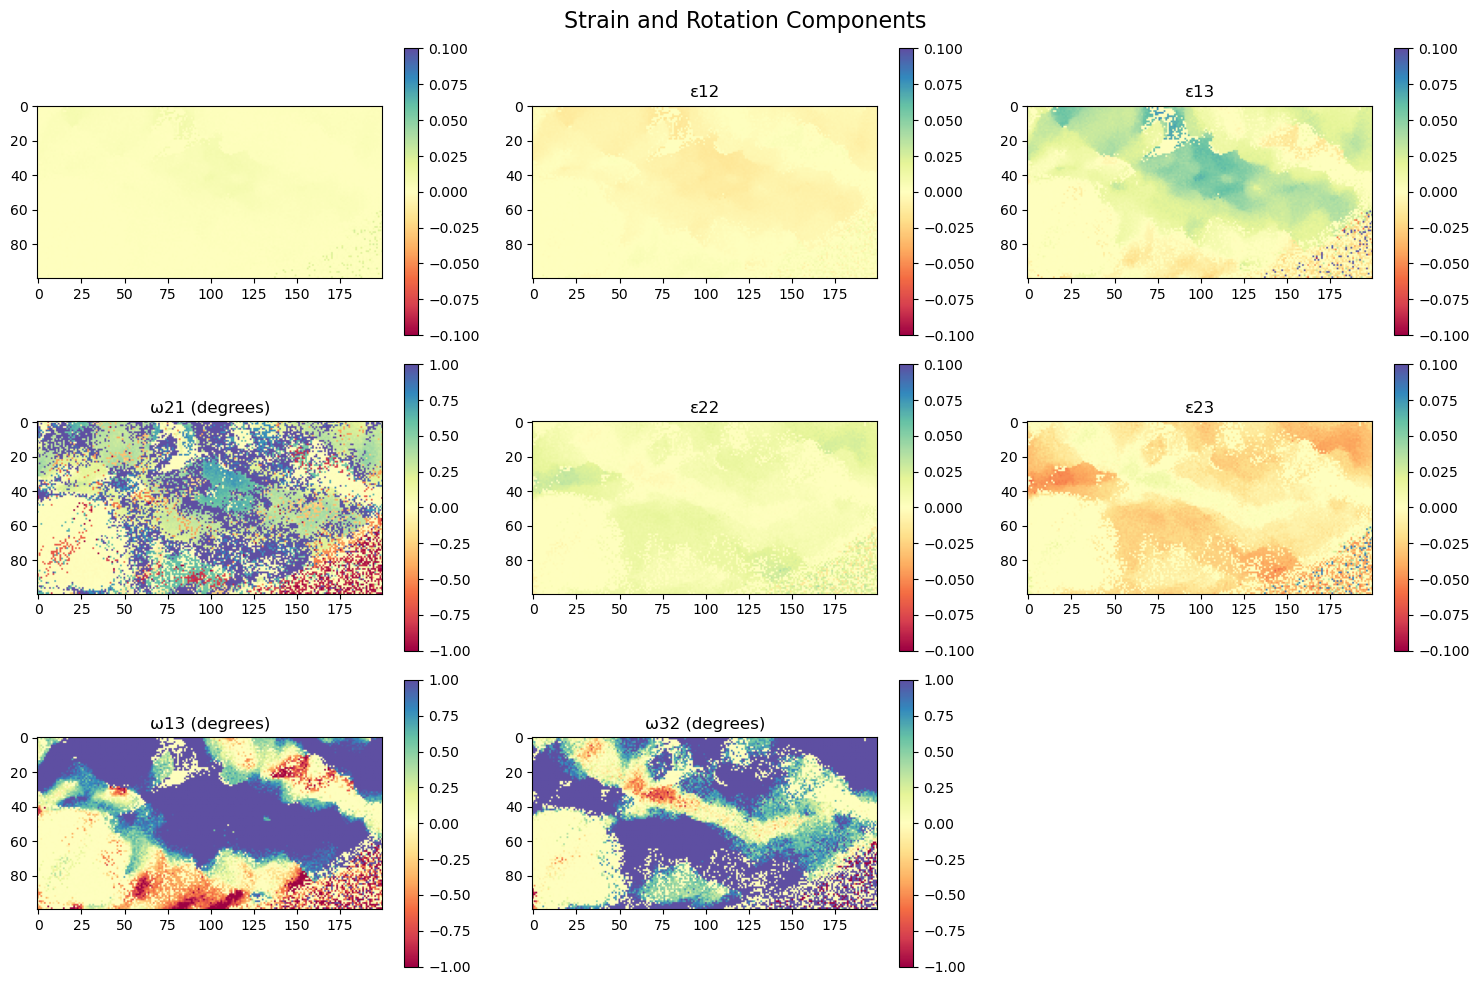

In [9]:

#plot strain components as subplots
fig, ax = plt.subplots(3, 3, figsize=(15, 10))

vmin = -1e-1
vmax = 1e-1
vmin_rot =-1.0
vmax_rot = 1.0

ax[0, 0].imshow(e11, cmap="Spectral", vmin=vmin, vmax=vmax)
cb1 = fig.colorbar(ax[0,0].imshow(e11, cmap="Spectral", vmin=vmin, vmax=vmax), ax=ax[0,0])
#cb1.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
# mark pixel (0,0)
# ax[0, 0].plot(50, 35, 'kx', markersize=12, markeredgewidth=2)
# ax[0, 0].set_title("ε11")

ax[0, 1].imshow(e12, cmap="Spectral", vmin=vmin, vmax=vmax)
cb2 = fig.colorbar(ax[0,1].imshow(e12, cmap="Spectral", vmin=vmin, vmax=vmax), ax=ax[0,1])
#cb2.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
ax[0, 1].set_title("ε12")

ax[0, 2].imshow(e13, cmap="Spectral", vmin=vmin, vmax=vmax)
cb3 = fig.colorbar(ax[0,2].imshow(e13, cmap="Spectral", vmin=vmin, vmax=vmax), ax=ax[0,2])
#cb3.set_ticks([-5e-2, -5e-3, 0, 5e-3, 5e-2])
ax[0, 2].set_title("ε13")

ax[1, 0].imshow(w21, cmap="Spectral", vmin=vmin, vmax=vmax)
cb4 = fig.colorbar(ax[1,0].imshow(w21, cmap="Spectral", vmin=vmin_rot, vmax=vmax_rot), ax=ax[1,0])
#cb4.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 0].set_title("ω21 (degrees)")

ax[1, 1].imshow(e22, cmap="Spectral", vmin=vmin, vmax=vmax)
cb5 = fig.colorbar(ax[1,1].imshow(e22, cmap="Spectral", vmin=vmin, vmax=vmax), ax=ax[1,1])
#cb5.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 1].set_title("ε22")

ax[1, 2].imshow(e23, cmap="Spectral", vmin=vmin, vmax=vmax)
cb6 = fig.colorbar(ax[1,2].imshow(e23, cmap="Spectral", vmin=vmin, vmax=vmax), ax=ax[1,2])
#cb6.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 2].set_title("ε23")

ax[2, 0].imshow(w13, cmap="Spectral", vmin=vmin, vmax=vmax)
cb7 = fig.colorbar(ax[2,0].imshow(w13, cmap="Spectral", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,0])
#cb7.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 0].set_title("ω13 (degrees)")

ax[2, 1].imshow(w32, cmap="Spectral", vmin=vmin, vmax=vmax)
cb8 = fig.colorbar(ax[2,1].imshow(w32, cmap="Spectral", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,1])
#cb8.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 1].set_title("ω32 (degrees)")
ax[2, 2].axis("off")
#set a supertitle
fig.suptitle(f"Strain and Rotation Components", fontsize=16)

plt.tight_layout()
plt.savefig(f"{foldername}/Strain_and_Rotation_Calculated - DETECTOR REFERENCE FRAME.png")

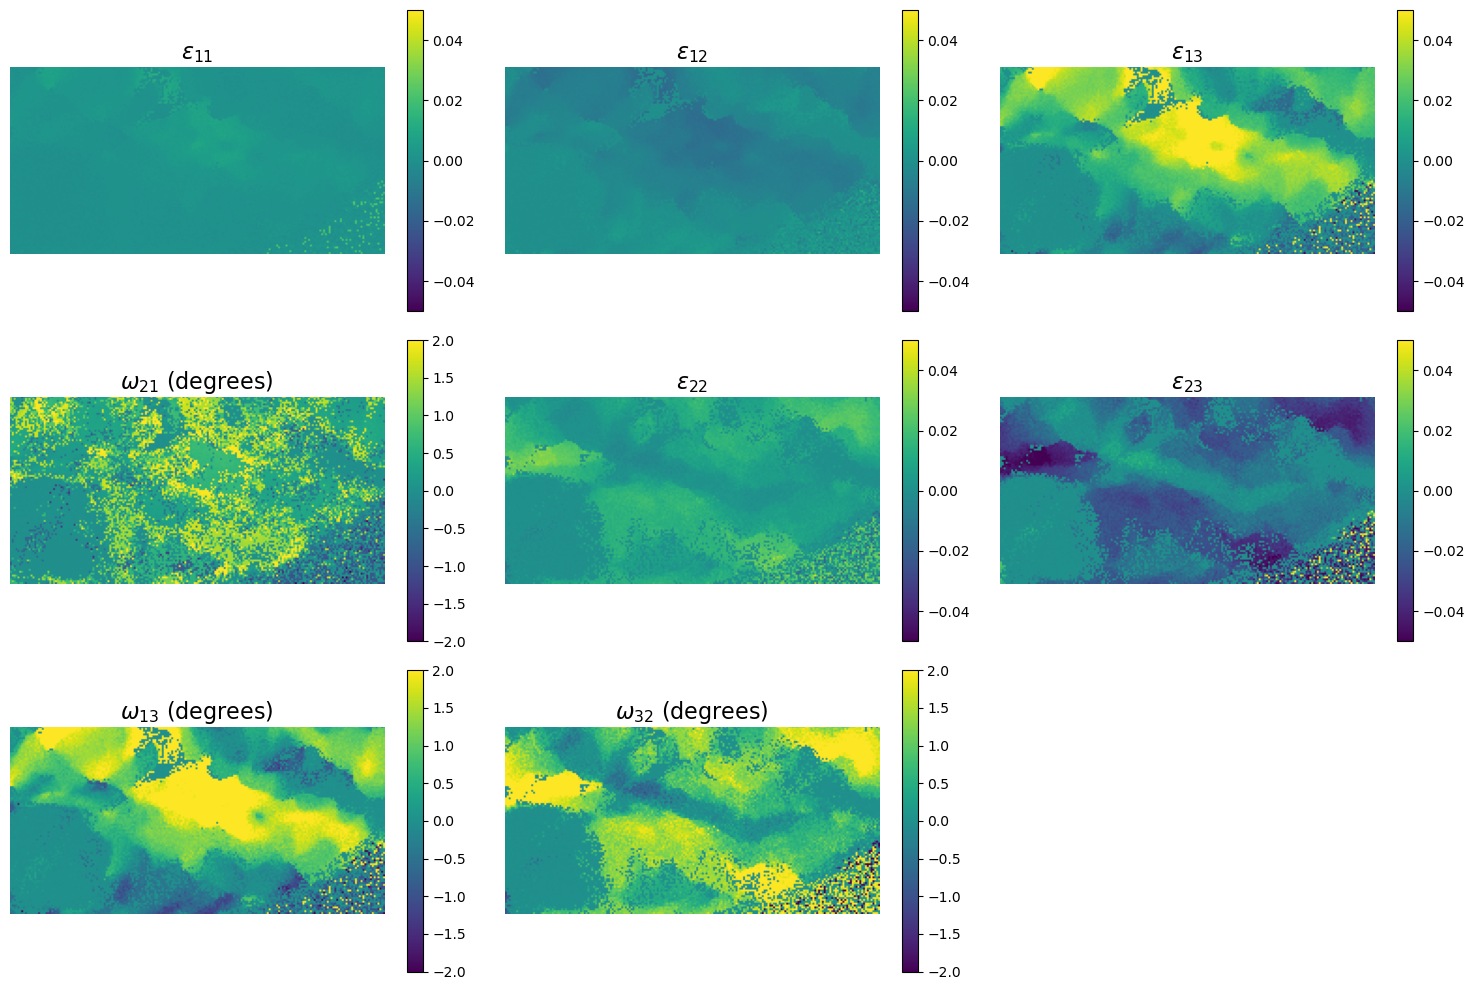

In [10]:

#plot strain components as subplots
fig, ax = plt.subplots(3, 3, figsize=(15, 10))

vmin = -5e-2
vmax = 5e-2
vmin_rot =-2.0
vmax_rot = 2.0

ax[0, 0].imshow(e11, cmap="viridis", vmin=vmin, vmax=vmax)
cb1 = fig.colorbar(ax[0,0].imshow(e11, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[0,0])
#cb1.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
# mark pixel (0,0)
#ax[0, 0].plot(50, 35, 'kx', markersize=12, markeredgewidth=2)
ax[0, 0].set_title(r"$ \epsilon_{11}$", fontsize=16)
ax[0,0].axis('off')

ax[0, 1].imshow(e12, cmap="viridis", vmin=vmin, vmax=vmax)
cb2 = fig.colorbar(ax[0,1].imshow(e12, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[0,1])
#cb2.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[0, 1].set_title(r"$ \epsilon_{12}$", fontsize=16)
ax[0,1].axis('off')

ax[0, 2].imshow(e13, cmap="viridis", vmin=vmin, vmax=vmax)
cb3 = fig.colorbar(ax[0,2].imshow(e13, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[0,2])
#cb3.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[0, 2].set_title(r"$ \epsilon_{13}$", fontsize=16)
ax[0,2].axis('off')


ax[1, 0].imshow(w21, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot)
cb4 = fig.colorbar(ax[1,0].imshow(w21, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot), ax=ax[1,0])
#cb4.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[1, 0].set_title(r"$ \omega_{21}$ (degrees)", fontsize=16)
ax[1,0].axis('off')

ax[1, 1].imshow(e22, cmap="viridis", vmin=vmin, vmax=vmax)
cb5 = fig.colorbar(ax[1,1].imshow(e22, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[1,1])
#cb5.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[1, 1].set_title(r"$ \epsilon_{22}$", fontsize=16)
ax[1,1].axis('off')

ax[1, 2].imshow(e23, cmap="viridis", vmin=vmin, vmax=vmax)
cb6 = fig.colorbar(ax[1,2].imshow(e23, cmap="viridis", vmin=vmin, vmax=vmax), ax=ax[1,2])
#cb6.set_ticks([-5e-2, -1e-2, 0, 1e-2, 5e-2])
ax[1, 2].set_title(r"$ \epsilon_{23}$", fontsize=16)
ax[1, 2].axis('off')

ax[2, 0].imshow(w13, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot)
cb7 = fig.colorbar(ax[2,0].imshow(w13, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,0])
#cb7.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 0].set_title(r"$ \omega_{13}$ (degrees)", fontsize=16)
ax[2, 0].axis('off')

ax[2, 1].imshow(w32, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot)
cb8 = fig.colorbar(ax[2,1].imshow(w32, cmap="viridis", vmin=vmin_rot, vmax=vmax_rot), ax=ax[2,1])
#cb8.set_ticks([-1e-2, -5e-3, 0, 5e-3, 1e-2])
ax[2, 1].set_title(r"$ \omega_{32}$ (degrees)", fontsize=16)
ax[2, 1].axis('off')
ax[2, 2].axis("off")
#set a supertitle
#fig.suptitle(f"Strain and Rotation Components", fontsize=16)

plt.tight_layout()
plt.savefig(f"{foldername}/Strain_and_Rotation_Calculated - viridis.png")

In [11]:
#also save each subplot individually
components = {
    "e11": e11,
    "e12": e12, 
    "e13": e13,
    "e22": e22,
    "e23": e23,
    "e33": e33,
    "w13": w13,
    "w21": w21,
    "w32": w32
}

for name, data in components.items():
    plt.figure(figsize=(6,5))
    plt.imshow(data, cmap="viridis", vmin=vmin, vmax=vmax)
    cb = plt.colorbar()
    #cb.set_ticks([-5e-2, -2.5e-2, 0, 2.5e-2, 5e-2])
    plt.title(f"{name} Component")
    plt.savefig(f"{foldername}/{name}_Calculated - DETECTOR REFERENCE FRAME.png")
    plt.close()

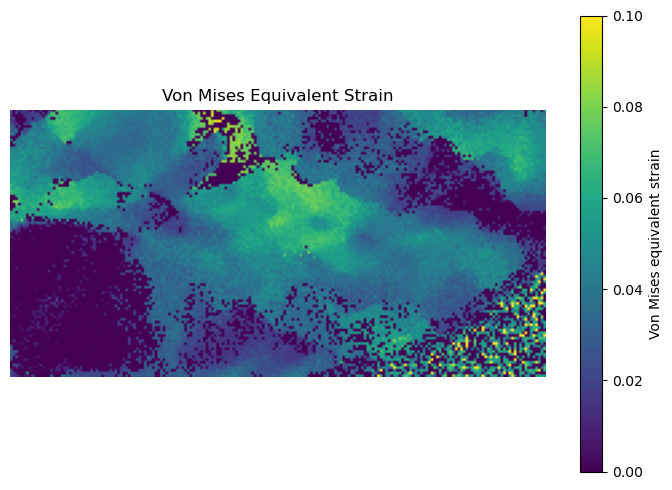

In [12]:
# Von Mises equivalent strain
von_mises = np.sqrt(
    (2.0 / 3.0) * (
        e11**2 + e22**2 + e33**2
        + 2 * e12**2 + 2 * e13**2 + 2 * e23**2
    )
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(von_mises, cmap="viridis", vmin=0, vmax=1e-1)
fig.colorbar(im, ax=ax, label="Von Mises equivalent strain")
ax.set_title("Von Mises Equivalent Strain")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{foldername}/von_mises_strain.png", dpi=200, bbox_inches="tight")
plt.show()

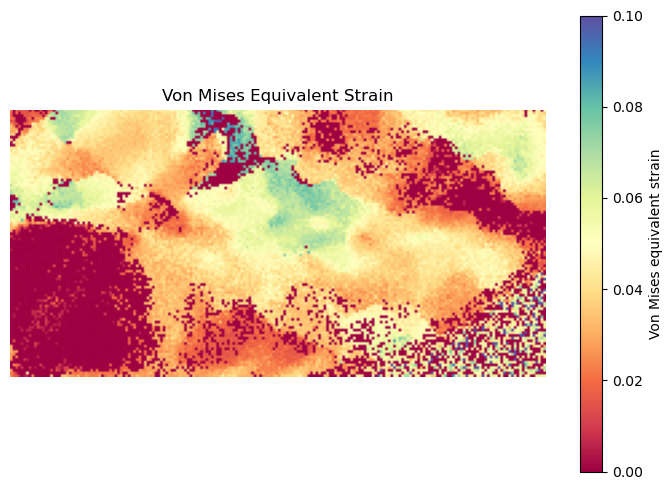

In [13]:
# Von Mises equivalent strain
von_mises = np.sqrt(
    (2.0 / 3.0) * (
        e11**2 + e22**2 + e33**2
        + 2 * e12**2 + 2 * e13**2 + 2 * e23**2
    )
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(von_mises, cmap="Spectral", vmin=0, vmax=1e-1)
fig.colorbar(im, ax=ax, label="Von Mises equivalent strain")
ax.set_title("Von Mises Equivalent Strain")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{foldername}/von_mises_strain.png", dpi=200, bbox_inches="tight")
plt.show()